In [ ]:
import numpy as np
import math
from copy import deepcopy
import sklearn.datasets
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Dataset

We import the dataset from Hastie & Tibshirani book.
This is an artificially generated binary classification problem. Labels are in the set $\{-1,+1\}$.

In [ ]:
X,y = sklearn.datasets.make_hastie_10_2()
X_train = X[0:8000,:]
y_train = y[0:8000]
X_test = X[8000:,:]
y_test = y[8000:]

# Adaboost implementation

Here we implement the Adaboost algorith. We shall assume that:
- that the problem is a binary classification problem with labels in $\{-1, +1\}$.
- that the weakModel can fit a weighted sample set by means of the call `weakModel.fit(X,y,sample_weight=w)` where `w` is a vector of length $n=|X|=|y|$.

In [ ]:
class AdaBoost:
    def __init__(self, weakModel, T):
      self.weakModel = weakModel
      self.T = T
      self.classifiers = []
      self.alphas = []
      self.wl_errors = []
      self.ens_errors = []

    def trainWeakModel(self, X, y, w):
      result = deepcopy(self.weakModel)
      result.fit(X,y,sample_weight=w)
      return result

    def weightedError(self, y, y_, w):
      return np.sum(w[y != y_])

    def fit(self, X, y, print_step=10):
      n = len(y)
      w = np.ones(n) / n

      ensemble_predictions = np.zeros(n)

      for t in range(self.T):
        mt = self.trainWeakModel(X,y,w)
        y_ = mt.predict(X)
        et = self.weightedError(y, y_, w)

        if et >= 0.5:
          raise ValueError("The weak learner did not provide et < 0.5")

        at = 0.5 * math.log( (1-et) / et )

        self.classifiers.append(mt)
        self.alphas.append(at)

        w = w * np.exp(-at * y * y_)
        w = w / np.sum(w)

        ensemble_predictions += at * y_
        ensemble_error = np.sum(np.sign(ensemble_predictions) != y) / n

        self.wl_errors.append(et)
        self.ens_errors.append(ensemble_error)

        if t > 1 and t % print_step == 0:
          print(f"step: {t} et: {et:.3f} ensemble error:{ensemble_error:.3f}")

      return self


    def predict(self, X):
      predictions = np.array([mt.predict(X) for mt in self.classifiers])
      return np.sign(np.array(self.alphas).dot(predictions))

# Testing with an SVM

Let us now see how our iplementation of AdaBoost performs on the dataset we loaded above. In this experiment we want the weak learning algorithm $A$ to be good, but not too much. An SVM with a polynomial kernel of degre 3 works fine for our needs.

The SVC implementation provided by sklearn does not work well when weights are normalized. The following code simply "denormalize" weights befor calling into SVC implementation.

In [ ]:
    class SVC_:
        def __init__(self, kernel="rbf", degree="3"):
            self.svc = SVC(kernel=kernel, degree=degree)

        def fit(self, X,y,sample_weight=None):
            if sample_weight is not None:
                sample_weight = sample_weight * len(X)

            self.svc.fit(X,y,sample_weight=sample_weight)
            return self

        def predict(self, X):
            return self.svc.predict(X)

In [ ]:
weakModel = SVC_(kernel="poly", degree=3)
adaboost = AdaBoost(weakModel, 30)
adaboost.fit(X_train, y_train, print_step=1)

y_train_ = adaboost.predict(X_train)
y_test_ = adaboost.predict(X_test)

0.34825000000000006
0.4034548874571775
0.38772390045628535
step: 2 et: 0.388 ensemble error:0.281
0.4186225995855673
step: 3 et: 0.419 ensemble error:0.281
0.3799163298257412
step: 4 et: 0.380 ensemble error:0.227
0.4187729161627387
step: 5 et: 0.419 ensemble error:0.227
0.37340037583440167
step: 6 et: 0.373 ensemble error:0.298
0.4246490193866246
step: 7 et: 0.425 ensemble error:0.205
0.3768723243198765
step: 8 et: 0.377 ensemble error:0.246
0.43272176694248754
step: 9 et: 0.433 ensemble error:0.209
0.3887065839743572
step: 10 et: 0.389 ensemble error:0.222
0.437505043445668
step: 11 et: 0.438 ensemble error:0.215
0.3888186304569199
step: 12 et: 0.389 ensemble error:0.195
0.4393823638176695
step: 13 et: 0.439 ensemble error:0.195
0.3873590688603061
step: 14 et: 0.387 ensemble error:0.187
0.4347847146209094
step: 15 et: 0.435 ensemble error:0.179
0.39219581346948146
step: 16 et: 0.392 ensemble error:0.199
0.44434318402718703
step: 17 et: 0.444 ensemble error:0.176
0.4014788623994554
st

In [ ]:
accuracy = np.sum(y_test_ != y_test)/len(y_test)

In [ ]:
print(accuracy)

0.19475


In [ ]:
svm = SVC(kernel="poly", degree=3)
svm.fit(X_train, y_train)

SVC(kernel='poly')

In [ ]:
svm_y = svm.predict(X_test)

In [ ]:
np.sum(svm_y != y_test) / len(y_test)

0.39625

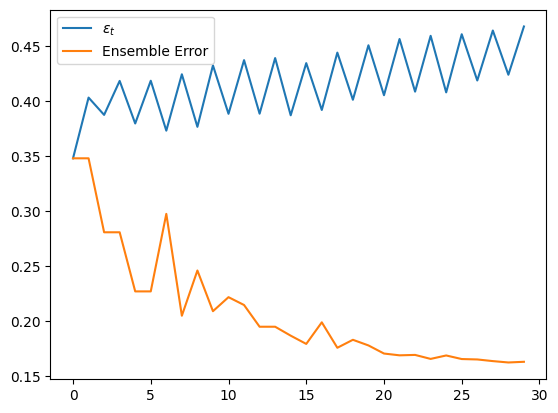

In [ ]:
plt.plot(adaboost.wl_errors, label="$\epsilon_t$")
plt.plot(adaboost.ens_errors, label="Ensemble Error")
plt.legend()

# Testing on the weakest of the weak learners

We now want to experiment with a VERY weak learner. The weak learner works as follows:

- it creates a random linear model by generating the needed weight vector $\mathbf{w}$ at random; each weight shall be sampled from U(-1,1);
- it evaluates the weighted loss $\epsilon_t$ on the given dataset and flip the linear model if $\epsilon_t > 0.5$
- at prediction time it predicts +1 if $\mathbf{x} \cdot \mathbf{w} > 0$ it predicts -1 otherwise.

In [ ]:
class RandomLinearModel:
    def loss(self, y, y_, w):
      return np.sum(w[y!=y_])

    def fit(self,X,y,sample_weight=None):
      self.colWeight = (np.random.rand(X.shape[1]) - 0.5) * 2.0
      y_ = self.predict(X)

      if self.loss(y, y_, sample_weight) >= 0.5:
        self.colWeight = -self.colWeight

      return self

    def predict(self,X):
      return np.sign(X @ self.colWeight)

Let us now learn an AdaBoost model using the RandomLinearModel weak learner printing every $K$ iterations the weighted error and the current error of the ensemble. Evaluate the training and test error of the final ensemble model.

In [ ]:
rs = RandomLinearModel()
a = AdaBoost(rs,10000)
a.fit(X_train,y_train)

y_train_ = a.predict(X_train)
y_test_ = a.predict(X_test)

step: 10 et: 0.494 ensemble error:0.488
step: 20 et: 0.497 ensemble error:0.482
step: 30 et: 0.493 ensemble error:0.478
step: 40 et: 0.492 ensemble error:0.474
step: 50 et: 0.498 ensemble error:0.474
step: 60 et: 0.488 ensemble error:0.472
step: 70 et: 0.496 ensemble error:0.467
step: 80 et: 0.499 ensemble error:0.467
step: 90 et: 0.494 ensemble error:0.469
step: 100 et: 0.497 ensemble error:0.468
step: 110 et: 0.500 ensemble error:0.466
step: 120 et: 0.499 ensemble error:0.462
step: 130 et: 0.493 ensemble error:0.456
step: 140 et: 0.497 ensemble error:0.455
step: 150 et: 0.498 ensemble error:0.453
step: 160 et: 0.494 ensemble error:0.452
step: 170 et: 0.496 ensemble error:0.454
step: 180 et: 0.499 ensemble error:0.452
step: 190 et: 0.498 ensemble error:0.454
step: 200 et: 0.496 ensemble error:0.449
step: 210 et: 0.494 ensemble error:0.448
step: 220 et: 0.493 ensemble error:0.448
step: 230 et: 0.497 ensemble error:0.445
step: 240 et: 0.490 ensemble error:0.444
step: 250 et: 0.498 ensem

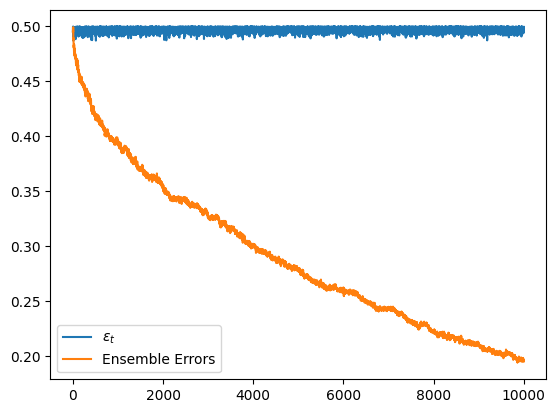

In [ ]:
plt.plot(a.wl_errors, label="$\epsilon_t$")
plt.plot(a.ens_errors, label="Ensemble Errors")
plt.legend()

In [ ]:
sum(y_train != y_train_) / len(y_train)

0.196125

In [ ]:
sum(y_test != y_test_) / len(y_test)

0.5025